# CREDIT RISK PREDICTIVE MODELING & EXPLAINABLE AI (XAI) WITH SHAP

**Fase 1: Machine Learning Classifier (XGBoost/LightGBM) & SHAP TreeExplainer Engine**

---
### 📋 Daftar Isi / Table of Contents
1. [Setup & Import Libraries](#1.-Setup-&-Import-Libraries)
2. [Load Preprocessed Dataset & Data Validation](#2.-Load-Preprocessed-Dataset-&-Data-Validation)
3. [Baseline Model Benchmarking](#3.-Baseline-Model-Benchmarking)
4. [Hyperparameter Tuning (XGBoost Classifier)](#4.-Hyperparameter-Tuning-(XGBoost-Classifier))
5. [Model Evaluation & Diagnostic Curves](#5.-Model-Evaluation-&-Diagnostic-Curves)
6. [Explainable AI (XAI) with SHAP](#6.-Explainable-AI-(XAI)-with-SHAP)
   - 6.1 Global Feature Importance & Beeswarm Summary
   - 6.2 SHAP Dependence Plots
   - 6.3 Local Applicant Explanations (Waterfall Plots)
   - 6.4 Automated Risk Drivers Extractor Function (for LLM Prompting)
7. [Export Model & Pipeline Artifacts](#7.-Export-Model-&-Pipeline-Artifacts)

## 1. Setup & Import Libraries

In [1]:
# Data handling & math
import pandas as pd
import numpy as np
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 11

# Scikit-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting Libraries
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Explainable AI
import shap
shap.initjs()

print(f"XGBoost version : {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version    : {shap.__version__}")

XGBoost version : 2.1.4
LightGBM version: 4.6.0
SHAP version    : 0.47.2


## 2. Load Preprocessed Dataset & Data Validation

Memuat file `preprocessed_credit_risk.csv` hasil dari notebook `01_eda_and_feature_eng.ipynb`.

In [2]:
# Load dataset
data_path = '../data/preprocessed_credit_risk.csv' if os.path.exists('../data/preprocessed_credit_risk.csv') else ('data/preprocessed_credit_risk.csv' if os.path.exists('data/preprocessed_credit_risk.csv') else 'preprocessed_credit_risk.csv')
df = pd.read_csv(data_path)

print(f"Dataset berhasil dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")

# Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['loan_status'])
y = df['loan_status'].astype(int)

# Hitung rasio imbalance untuk scale_pos_weight
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos_weight_val = neg_count / pos_count

print(f"Target Non-Default (0) : {neg_count:,} ({neg_count/len(y)*100:.2f}%)")
print(f"Target Default (1)     : {pos_count:,} ({pos_count/len(y)*100:.2f}%)")
print(f"Calculated scale_pos_weight: {scale_pos_weight_val:.3f}")

# Stratified Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Dataset berhasil dimuat: 32,407 baris x 23 kolom
Target Non-Default (0) : 25,319 (78.13%)
Target Default (1)     : 7,088 (21.87%)
Calculated scale_pos_weight: 3.572
X_train shape: (25925, 22) | X_test shape: (6482, 22)


## 3. Baseline Model Benchmarking

Membandingkan 4 model klasifikasi (Logistic Regression terstandarisasi, Random Forest, LightGBM, dan XGBoost) menggunakan **5-Fold Stratified Cross-Validation**.

In [3]:
# Inisialisasi model kandidat
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    'Random Forest': RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(scale_pos_weight=scale_pos_weight_val, random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight_val, eval_metric='logloss', random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}

benchmark_results = []

print("Memulai Cross-Validation Benchmarking...")
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    roc_mean = scores['test_roc_auc'].mean()
    f1_mean = scores['test_f1'].mean()
    benchmark_results.append({
        'Model': name,
        'ROC-AUC Mean': roc_mean,
        'ROC-AUC Std': scores['test_roc_auc'].std(),
        'F1-Score Mean': f1_mean,
        'F1-Score Std': scores['test_f1'].std(),
        'Precision Mean': scores['test_precision'].mean(),
        'Recall Mean': scores['test_recall'].mean()
    })
    print(f"  [+] {name:20s} | ROC-AUC: {roc_mean:.4f} | F1: {f1_mean:.4f}")

df_benchmark = pd.DataFrame(benchmark_results).sort_values(by='ROC-AUC Mean', ascending=False).reset_index(drop=True)
df_benchmark

Memulai Cross-Validation Benchmarking...
  [+] Logistic Regression  | ROC-AUC: 0.8640 | F1: 0.6194
  [+] Random Forest        | ROC-AUC: 0.9316 | F1: 0.8151
  [+] LightGBM             | ROC-AUC: 0.9447 | F1: 0.8020
  [+] XGBoost              | ROC-AUC: 0.9440 | F1: 0.8096


,Model,ROC-AUC Mean,ROC-AUC Std,F1-Score Mean,F1-Score Std,Precision Mean,Recall Mean
0,LightGBM,0.944677,0.003668,0.801971,0.004391,0.816990,0.787654
1,XGBoost,0.943980,0.003019,0.809626,0.004437,0.826129,0.793827
2,Random Forest,0.931623,0.003048,0.815127,0.003197,0.966180,0.704938
3,Logistic Regression,0.864027,0.006531,0.619393,0.009523,0.513923,0.779541


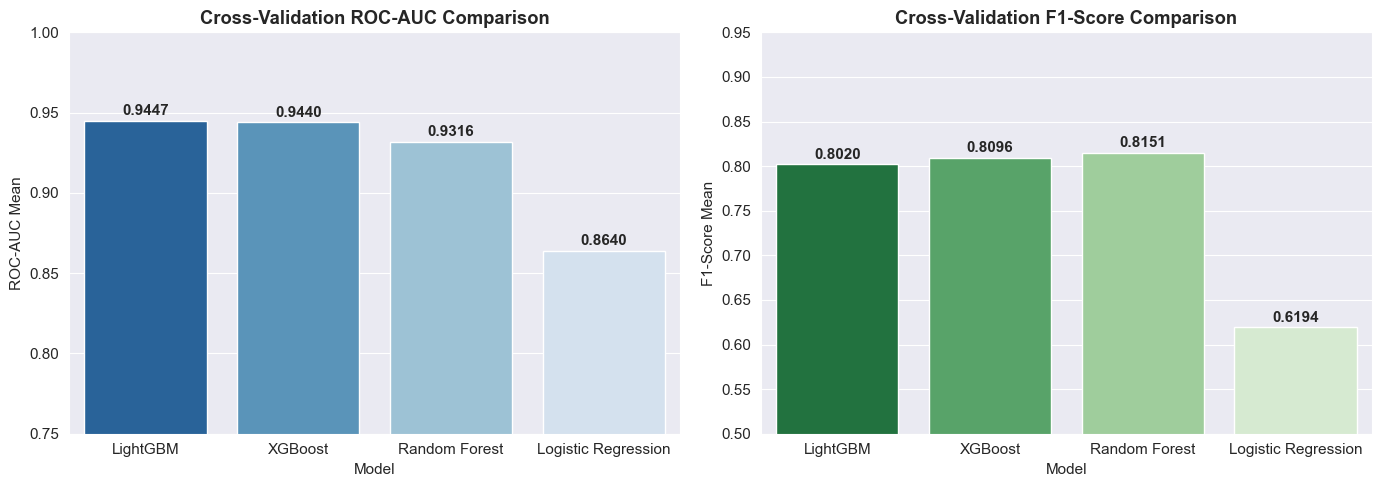

In [4]:
# Visualisasi Perbandingan Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_benchmark, x='Model', y='ROC-AUC Mean', ax=axes[0], palette='Blues_r')
axes[0].set_title('Cross-Validation ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylim(0.75, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

sns.barplot(data=df_benchmark, x='Model', y='F1-Score Mean', ax=axes[1], palette='Greens_r')
axes[1].set_title('Cross-Validation F1-Score Comparison', fontweight='bold')
axes[1].set_ylim(0.5, 0.95)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning (XGBoost Classifier)

Melakukan optimalisasi hyperparameter pada **XGBoost Classifier** menggunakan `RandomizedSearchCV` untuk memaksimalkan metrik **ROC-AUC**.

In [5]:
# Ruang pencarian parameter (Hyperparameter Search Space)
param_dist = {
    'n_estimators': [150, 200, 300, 400],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.08, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'scale_pos_weight': [scale_pos_weight_val * factor for factor in [0.8, 1.0, 1.2]]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Menjalankan RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print("\n[+] Tuning Selesai!")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
print("Best Parameters:")
for k, v in random_search.best_params_.items():
    print(f"  - {k}: {v}")

best_xgb = random_search.best_estimator_

Menjalankan RandomizedSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

[+] Tuning Selesai!
Best CV ROC-AUC: 0.9466
Best Parameters:
  - subsample: 0.9
  - scale_pos_weight: 2.8576749435665914
  - n_estimators: 150
  - min_child_weight: 1
  - max_depth: 6
  - learning_rate: 0.1
  - gamma: 0.2
  - colsample_bytree: 0.9


## 5. Model Evaluation & Diagnostic Curves

Mengevaluasi performa model terbaik pada **Test Set** (data yang belum pernah dilihat model).

In [6]:
# Prediksi pada Test Set
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)

# Hitung Metrik Utama
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_pr_auc = average_precision_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec = recall_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 50)
print("HASIL EVALUASI MODEL PADA TEST SET")
print("=" * 50)
print(f"ROC-AUC Score    : {test_roc_auc:.4f} (Target PRD: >= 0.88) {'[MEMENUHI]' if test_roc_auc >= 0.88 else '[BELUM]'}")
print(f"PR-AUC Score     : {test_pr_auc:.4f}")
print(f"F1-Score         : {test_f1:.4f} (Target PRD: >= 0.80) {'[MEMENUHI]' if test_f1 >= 0.80 else '[CATATAN]'}")
print(f"Precision        : {test_prec:.4f}")
print(f"Recall           : {test_rec:.4f}")
print(f"Accuracy         : {test_acc:.4f}")
print("-" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Default (0)', 'Default (1)']))

HASIL EVALUASI MODEL PADA TEST SET
ROC-AUC Score    : 0.9494 (Target PRD: >= 0.88) [MEMENUHI]
PR-AUC Score     : 0.9065
F1-Score         : 0.8250 (Target PRD: >= 0.80) [MEMENUHI]
Precision        : 0.8600
Recall           : 0.7927
Accuracy         : 0.9264
--------------------------------------------------

Classification Report:
                 precision    recall  f1-score   support

Non-Default (0)       0.94      0.96      0.95      5064
    Default (1)       0.86      0.79      0.82      1418

       accuracy                           0.93      6482
      macro avg       0.90      0.88      0.89      6482
   weighted avg       0.92      0.93      0.93      6482



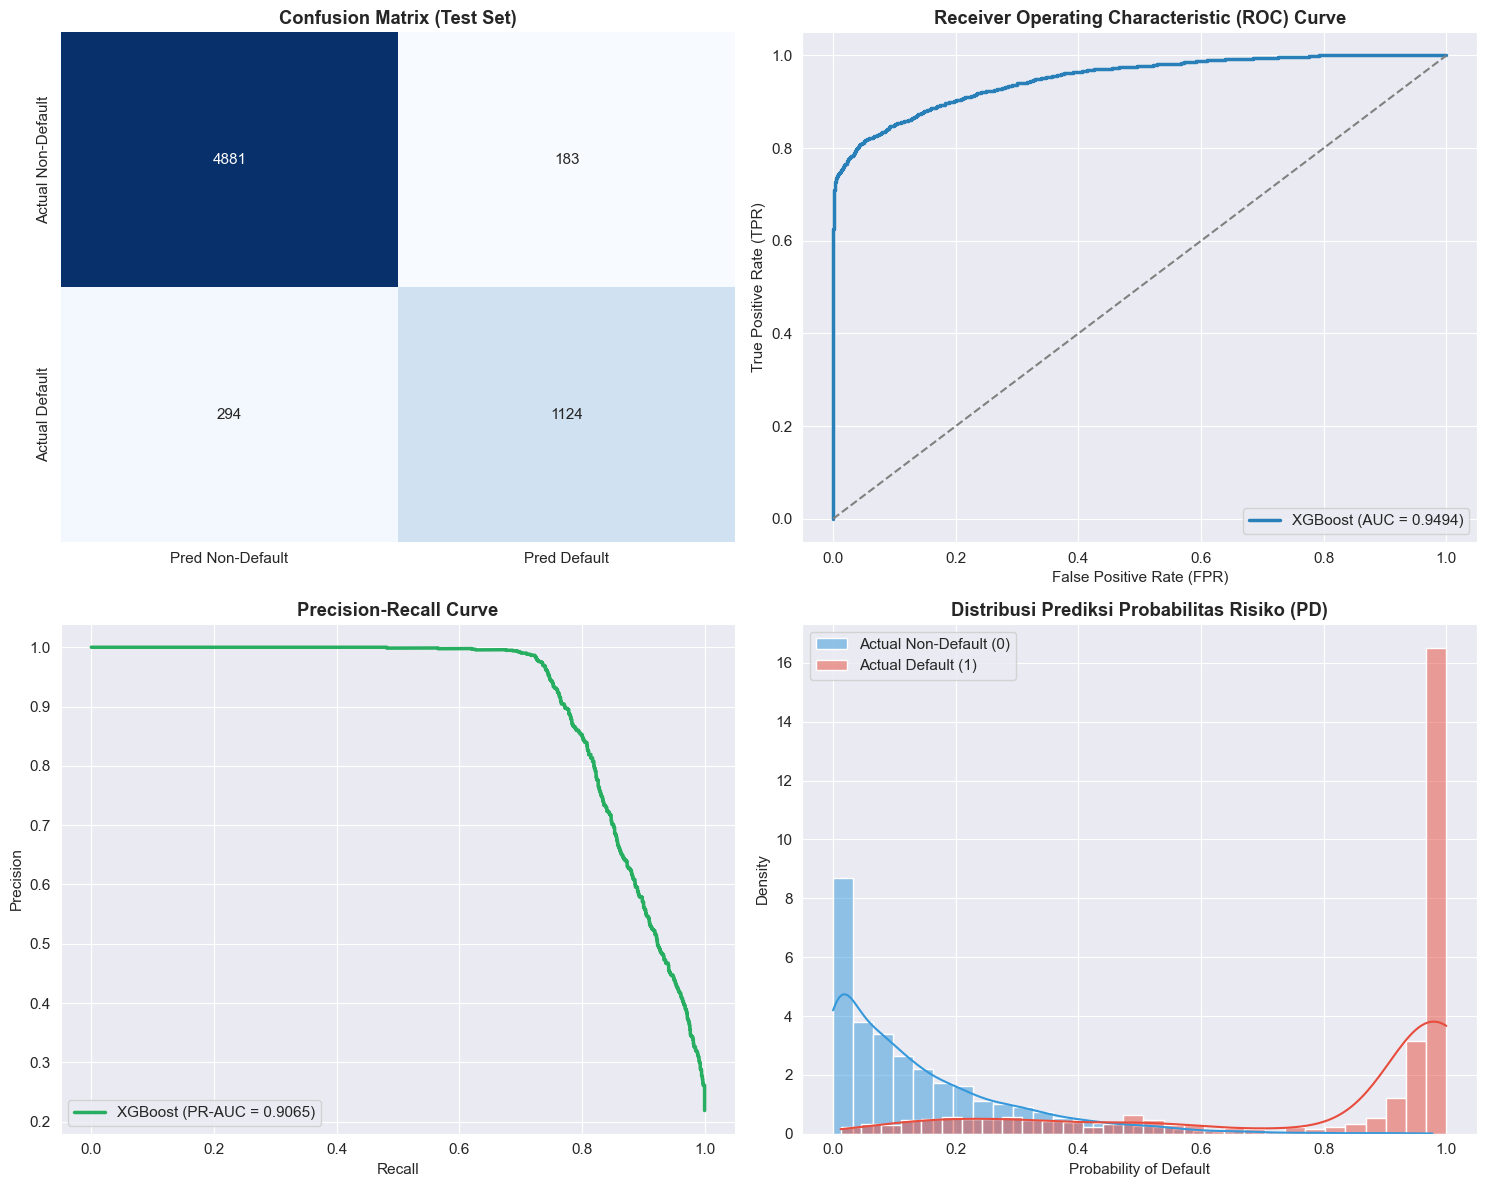

In [7]:
# Visualisasi Diagnostic: Confusion Matrix, ROC Curve, PR Curve, & Prediction Probability Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Pred Non-Default', 'Pred Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
axes[0, 0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'XGBoost (AUC = {test_roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0, 1].set_xlabel('False Positive Rate (FPR)')
axes[0, 1].set_ylabel('True Positive Rate (TPR)')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
axes[0, 1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 0].plot(rec_curve, prec_curve, color='#27ae60', lw=2.5, label=f'XGBoost (PR-AUC = {test_pr_auc:.4f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].legend(loc='lower left')

# 4. Distribusi Probabilitas Default (Probability of Default / PD)
sns.histplot(y_pred_proba[y_test == 0], bins=30, color='#3498db', label='Actual Non-Default (0)', kde=True, ax=axes[1, 1], stat='density', alpha=0.5)
sns.histplot(y_pred_proba[y_test == 1], bins=30, color='#e74c3c', label='Actual Default (1)', kde=True, ax=axes[1, 1], stat='density', alpha=0.5)
axes[1, 1].set_title('Distribusi Prediksi Probabilitas Risiko (PD)', fontweight='bold')
axes[1, 1].set_xlabel('Probability of Default')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Explainable AI (XAI) with SHAP

Menggunakan `shap.TreeExplainer` untuk mengekstrak kontribusi matematis (*Shapley Additive Explanations*) setiap fitur terhadap penilaian risiko kredit.

In [8]:
# Inisialisasi SHAP TreeExplainer dengan model XGBoost
explainer = shap.TreeExplainer(best_xgb)

# Hitung SHAP values untuk seluruh data test (atau sampel representatif jika ingin super cepat)
print("Menghitung SHAP values...")
shap_values = explainer(X_test)
print(f"SHAP values shape: {shap_values.values.shape}")

Menghitung SHAP values...
SHAP values shape: (6482, 22)


### 6.1 Global Feature Importance & Beeswarm Summary Plot

- **Bar Plot**: Menunjukkan ranking kepentingan absolut rata-rata ($|\text{SHAP}|$ value).
- **Beeswarm Plot**: Menunjukkan arah pengaruh (positif = menaikkan risiko gagal bayar, negatif = meredam risiko) beserta nilai aktual fitur (merah = tinggi, biru = rendah).

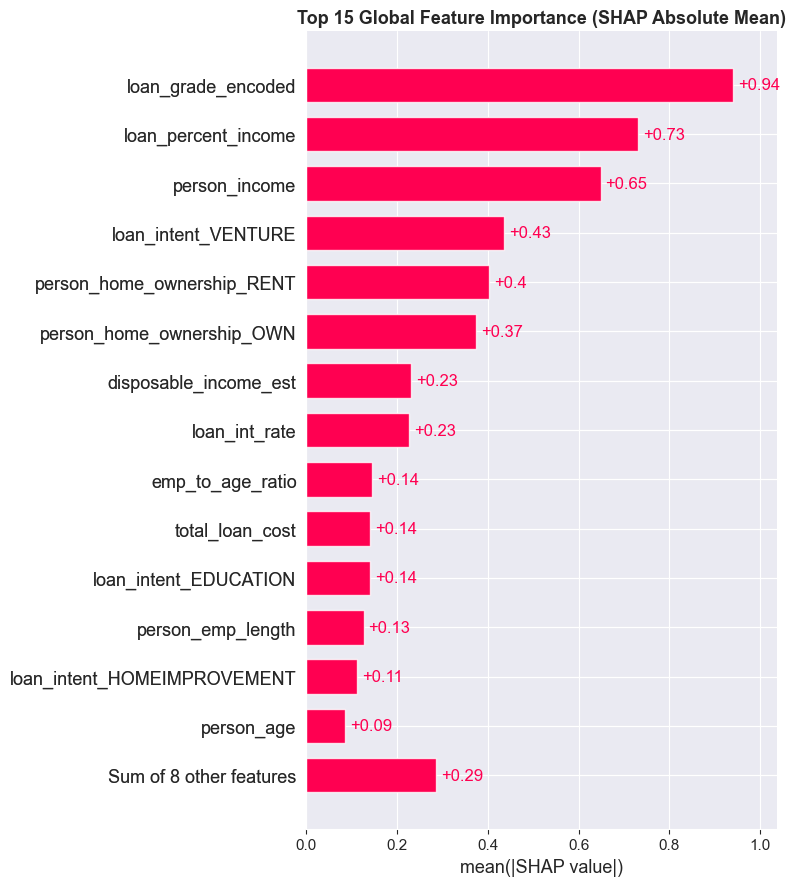

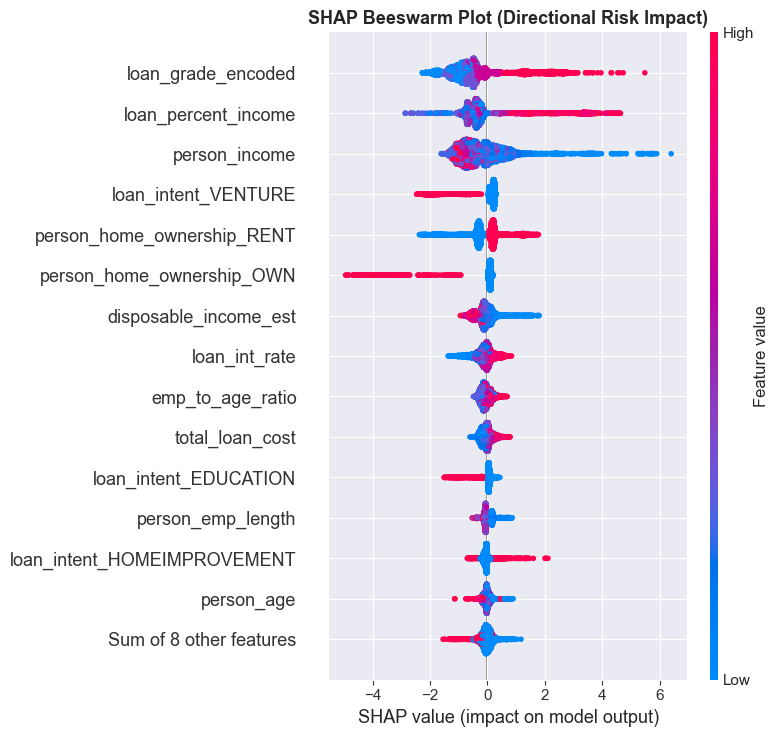

In [9]:
# 1. Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Top 15 Global Feature Importance (SHAP Absolute Mean)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# 2. Summary Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot (Directional Risk Impact)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 SHAP Dependence Plots

Menganalisis hubungan non-linear dan efek ambang batas (*threshold effect*) antara nilai fitur spesifik terhadap nilai SHAP.

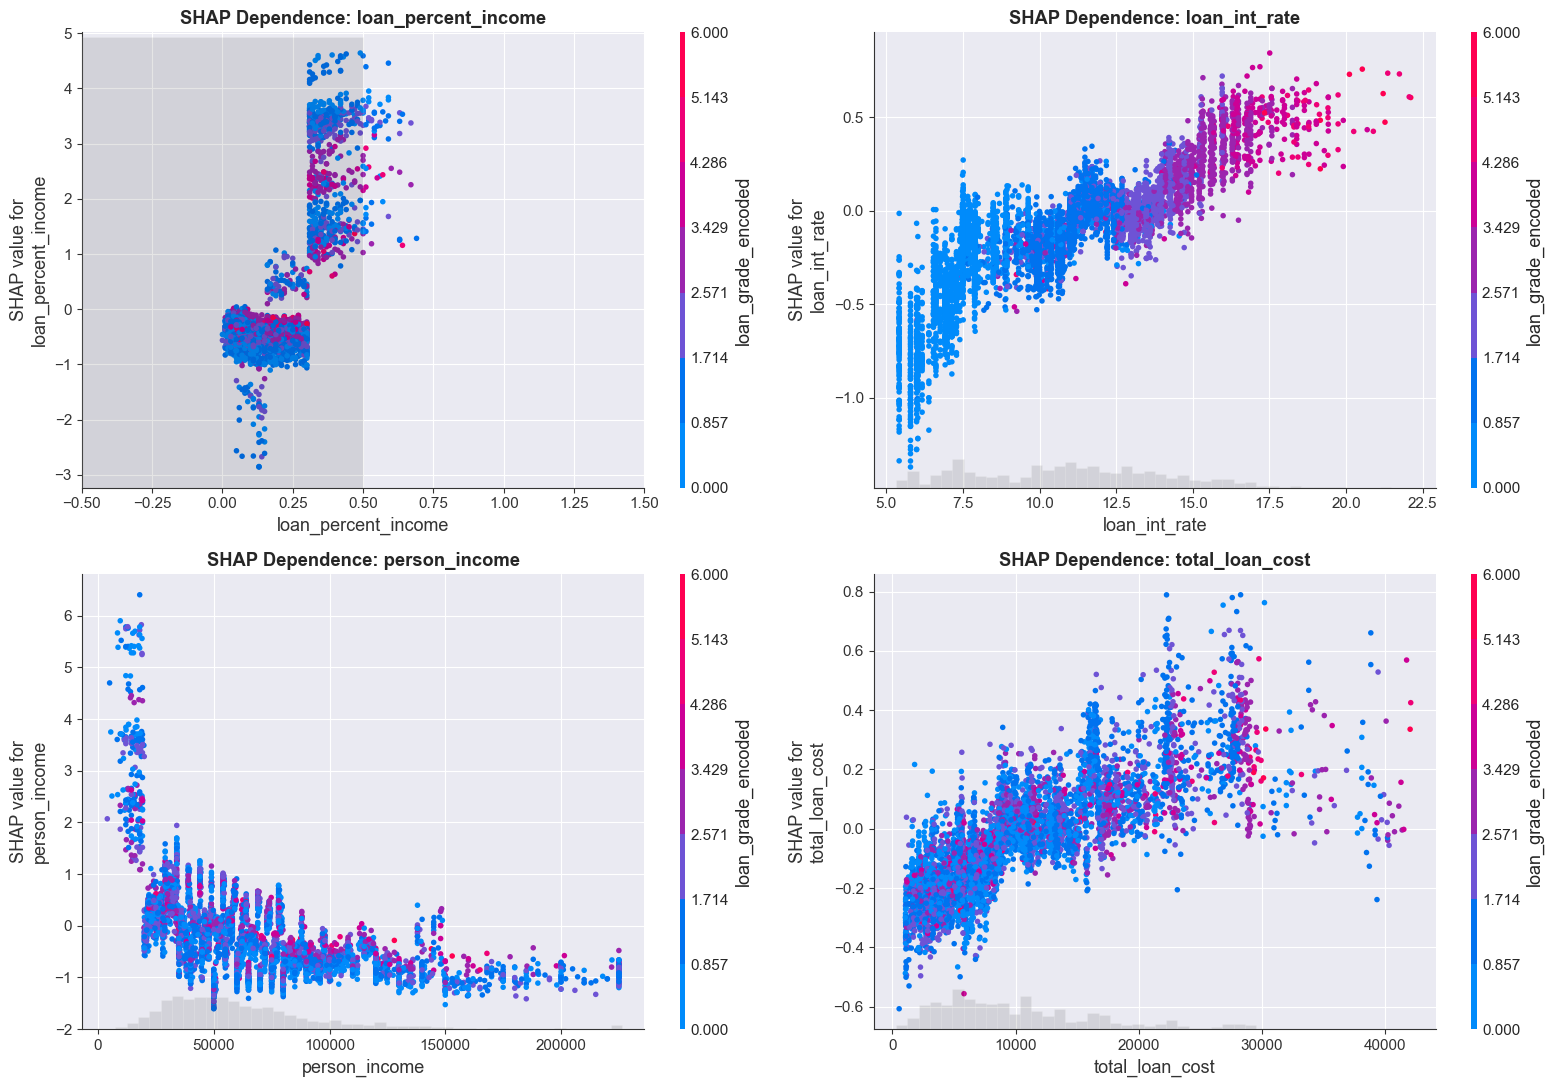

In [10]:
# Dependence plots untuk fitur pendorong risiko teratas
top_features = ['loan_percent_income', 'loan_int_rate', 'person_income', 'total_loan_cost']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    plt.sca(axes[i])
    shap.plots.scatter(shap_values[:, feat], color=shap_values[:, 'loan_grade_encoded'], ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Local Applicant Explanations (Individual Underwriting Inspection)

Visualisasi kontribusi setiap fitur untuk profil individu nasabah tertentu menggunakan **SHAP Waterfall Plot**.

[Kasus 1] Nasabah High Risk (Index Test: 9)
  Probabilitas Default: 99.30%


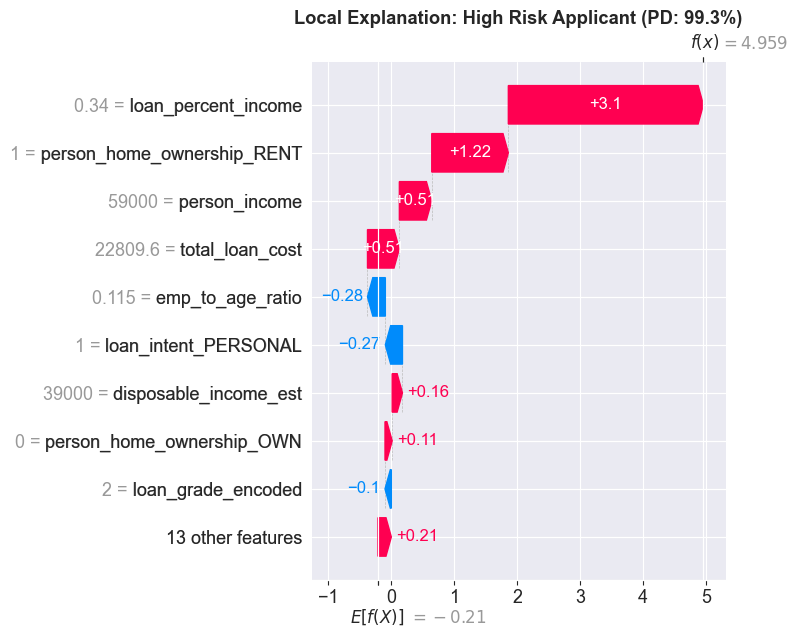


[Kasus 2] Nasabah Low Risk (Index Test: 0)
  Probabilitas Default: 0.10%


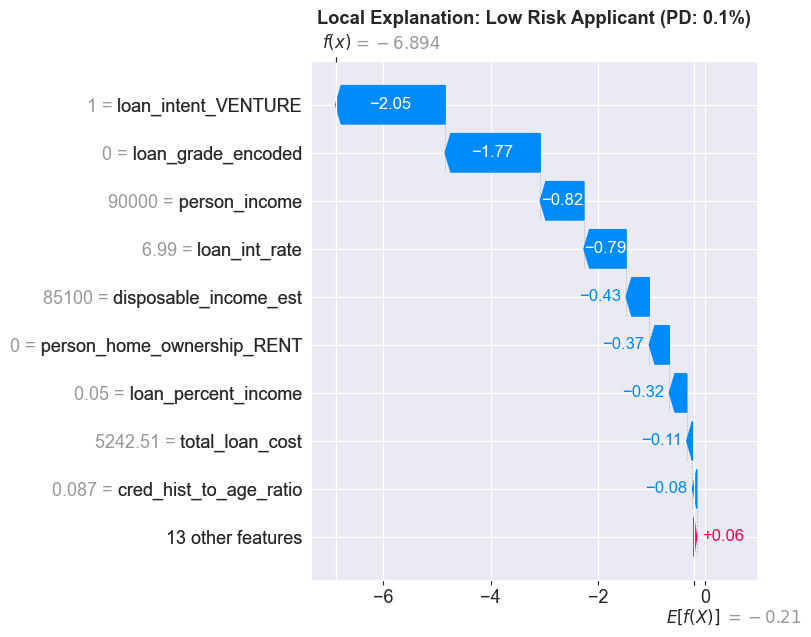

In [11]:
# Kasus 1: Nasabah dengan Prediksi Risiko Gagal Bayar Tinggi (High Risk Default)
high_risk_idx = np.where((y_pred == 1) & (y_test.values == 1))[0][0]
print(f"[Kasus 1] Nasabah High Risk (Index Test: {high_risk_idx})")
print(f"  Probabilitas Default: {y_pred_proba[high_risk_idx]*100:.2f}%")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.title(f'Local Explanation: High Risk Applicant (PD: {y_pred_proba[high_risk_idx]*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

# Kasus 2: Nasabah dengan Profil Aman / Lunas (Low Risk Non-Default)
low_risk_idx = np.where((y_pred == 0) & (y_test.values == 0))[0][0]
print(f"\n[Kasus 2] Nasabah Low Risk (Index Test: {low_risk_idx})")
print(f"  Probabilitas Default: {y_pred_proba[low_risk_idx]*100:.2f}%")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[low_risk_idx], max_display=10, show=False)
plt.title(f'Local Explanation: Low Risk Applicant (PD: {y_pred_proba[low_risk_idx]*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Automated Risk Drivers Extractor Function (for LLM Prompting & API Serving)

Fungsi pembantu yang mengekstrak nilai **Probability of Default (PD)**, **Top Risk Escalators** (faktor pemicu risiko positif), dan **Top Mitigating Factors** (faktor pereda risiko negatif) dalam format kamus/JSON terstruktur yang siap disuntikkan ke prompt LLM.

In [12]:
def extract_shap_explanation(model, explainer, feature_row, feature_names, top_n=3):
    """
    Mengekstrak analisis risiko terstruktur berbasis SHAP untuk 1 profil nasabah.
    
    Parameters:
        model: Model XGBoost terlatih
        explainer: shap.TreeExplainer
        feature_row: DataFrame atau 2D-array berdimensi (1, n_features)
        feature_names: List nama fitur
        top_n: Jumlah faktor teratas yang ingin diekstrak
    
    Returns:
        dict: Ringkasan probabilitas, faktor pemicu risiko, dan faktor pereda risiko.
    """
    if isinstance(feature_row, pd.Series):
        feature_df = pd.DataFrame([feature_row])
    elif isinstance(feature_row, np.ndarray):
        feature_df = pd.DataFrame(feature_row, columns=feature_names)
    else:
        feature_df = feature_row.copy()
        
    # Prediksi probabilitas
    prob_default = float(model.predict_proba(feature_df)[0, 1])
    
    # SHAP calculation
    shap_obj = explainer(feature_df)
    sv = shap_obj.values[0]
    
    # Susun kontribusi fitur
    contributions = []
    for feat_name, feat_val, s_val in zip(feature_names, feature_df.iloc[0].values, sv):
        contributions.append({
            'feature': feat_name,
            'value': float(feat_val),
            'shap_value': float(s_val)
        })
        
    df_contrib = pd.DataFrame(contributions)
    
    # Top Risk Escalators (SHAP > 0, kontribusi menaikkan risiko default)
    risk_escalators = df_contrib[df_contrib['shap_value'] > 0].sort_values(by='shap_value', ascending=False).head(top_n).to_dict('records')
    
    # Top Mitigating Factors (SHAP < 0, kontribusi meredam risiko default)
    mitigating_factors = df_contrib[df_contrib['shap_value'] < 0].sort_values(by='shap_value', ascending=True).head(top_n).to_dict('records')
    
    # Risk Tier classification
    if prob_default < 0.20:
        risk_tier = 'LOW_RISK'
        recommendation = 'APPROVE'
    elif prob_default < 0.50:
        risk_tier = 'MEDIUM_RISK'
        recommendation = 'MANUAL_REVIEW'
    else:
        risk_tier = 'HIGH_RISK'
        recommendation = 'REJECT'
        
    return {
        'probability_of_default': round(prob_default, 4),
        'probability_of_default_pct': f"{prob_default * 100:.2f}%",
        'risk_tier': risk_tier,
        'preliminary_recommendation': recommendation,
        'base_value': float(shap_obj.base_values[0]) if hasattr(shap_obj, 'base_values') else 0.0,
        'top_risk_escalators': risk_escalators,
        'top_mitigating_factors': mitigating_factors
    }

# Uji fungsi pada 1 baris sampel test
sample_row = X_test.iloc[[0]]
sample_summary = extract_shap_explanation(best_xgb, explainer, sample_row, X.columns.tolist())
print("Contoh Output JSON Ekstraksi SHAP:")
print(json.dumps(sample_summary, indent=2))

Contoh Output JSON Ekstraksi SHAP:
{
  "probability_of_default": 0.001,
  "probability_of_default_pct": "0.10%",
  "risk_tier": "LOW_RISK",
  "preliminary_recommendation": "APPROVE",
  "base_value": -0.210395947098732,
  "top_risk_escalators": [
    {
      "feature": "loan_intent_EDUCATION",
      "value": 0.0,
      "shap_value": 0.0809846743941307
    },
    {
      "feature": "person_home_ownership_OWN",
      "value": 0.0,
      "shap_value": 0.06395931541919708
    },
    {
      "feature": "person_age",
      "value": 23.0,
      "shap_value": 0.0341605469584465
    }
  ],
  "top_mitigating_factors": [
    {
      "feature": "loan_intent_VENTURE",
      "value": 1.0,
      "shap_value": -2.04500675201416
    },
    {
      "feature": "loan_grade_encoded",
      "value": 0.0,
      "shap_value": -1.7739942073822021
    },
    {
      "feature": "person_income",
      "value": 90000.0,
      "shap_value": -0.8158696293830872
    }
  ]
}


## 7. Export Model & Pipeline Artifacts

Mengekspor model dan file konfigurasi metadata yang akan digunakan oleh modul inferensi Streamlit (`app/utils_ml.py`) dan pembuatan dataset instruksi (`03_dataset_generation.ipynb`).

In [13]:
# Buat direktori models jika belum ada
models_dir = '../models' if os.path.exists('../models') else ('models' if os.path.exists('models') else 'models')
os.makedirs(models_dir, exist_ok=True)

# 1. Simpan model XGBoost terbaik
model_save_path = os.path.join(models_dir, 'credit_xgboost_model.pkl')
joblib.dump(best_xgb, model_save_path)
print(f"[+] Model XGBoost berhasil diekspor ke '{model_save_path}'")

# 2. Simpan metadata model (daftar fitur, threshold, metrik)
metadata = {
    'model_type': 'XGBClassifier',
    'features': X.columns.tolist(),
    'n_features': len(X.columns),
    'metrics': {
        'roc_auc': float(test_roc_auc),
        'pr_auc': float(test_pr_auc),
        'f1_score': float(test_f1),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'accuracy': float(test_acc)
    },
    'scale_pos_weight': float(scale_pos_weight_val),
    'best_params': {k: (float(v) if isinstance(v, (np.floating, float)) else (int(v) if isinstance(v, (np.integer, int)) else v)) for k, v in random_search.best_params_.items()}
}

metadata_save_path = os.path.join(models_dir, 'model_metadata.json')
with open(metadata_save_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f"[+] Model metadata berhasil disimpan ke '{metadata_save_path}'")

# 3. Simpan sampel data test untuk verifikasi & app testing
sample_test_path = os.path.join('../data' if os.path.exists('../data') else 'data', 'sample_test_records.json')
test_sample_df = X_test.head(10).copy()
test_sample_df['actual_loan_status'] = y_test.head(10).values
test_sample_df.to_json(sample_test_path, orient='records', indent=2)
print(f"[+] Sampel record test berhasil disimpan ke '{sample_test_path}'")

print("\n=======================================================")
print("FASE 1 (MODELING & SHAP ENGINE) SELESAI DENGAN SUKSES!")
print("=======================================================")

[+] Model XGBoost berhasil diekspor ke '../models\credit_xgboost_model.pkl'
[+] Model metadata berhasil disimpan ke '../models\model_metadata.json'
[+] Sampel record test berhasil disimpan ke '../data\sample_test_records.json'

FASE 1 (MODELING & SHAP ENGINE) SELESAI DENGAN SUKSES!
